In [60]:
!pip install ultralytics opencv-python matplotlib

In [61]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

In [62]:
# Load pretrained YOLOv8 nano model
yolo_model = YOLO("yolov8n.pt")

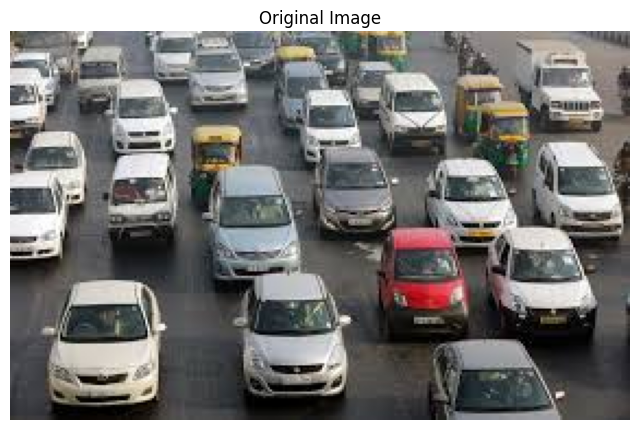

In [63]:
image_path = "test.jpg"   # change file name if needed
image = cv2.imread(image_path)

# Convert BGR to RGB for display
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [64]:
results = yolo_model(image_path)


image 1/1 /content/test.jpg: 416x640 17 cars, 4 buss, 2 trucks, 9.0ms
Speed: 1.7ms preprocess, 9.0ms inference, 1.4ms postprocess per image at shape (1, 3, 416, 640)


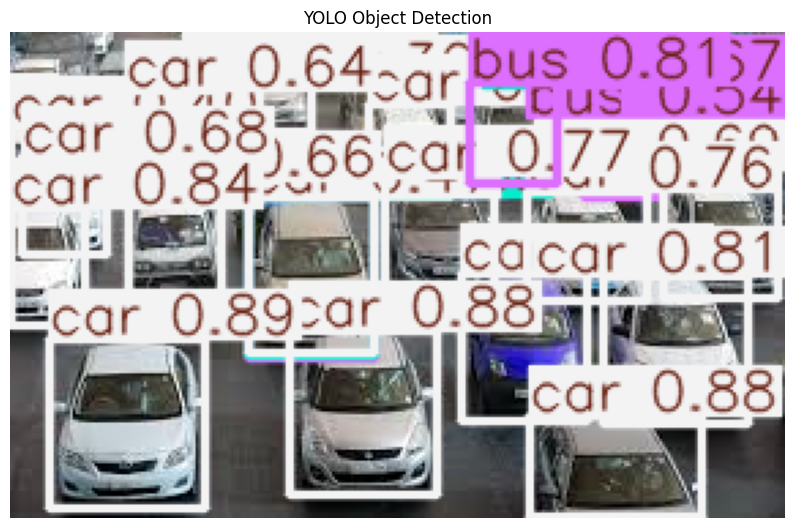

In [65]:
result_image = results[0].plot()

plt.figure(figsize=(10, 8))
plt.imshow(result_image)
plt.title("YOLO Object Detection")
plt.axis("off")
plt.show()

(np.float64(-0.5), np.float64(283.5), np.float64(177.5), np.float64(-0.5))

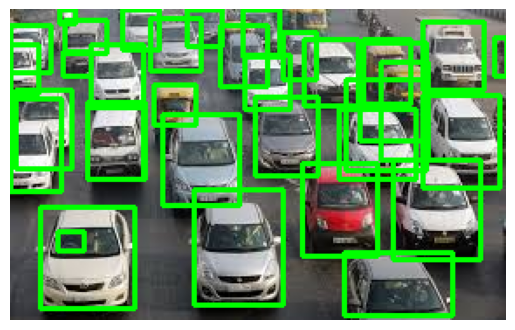

In [59]:
import torch
import torchvision
from PIL import Image
import matplotlib.pyplot as plt
import cv2

# Load pretrained Faster R-CNN
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
model.eval()

# Load image
img = Image.open("test.jpg")
transform = torchvision.transforms.ToTensor()
img_tensor = transform(img)

# Prediction
with torch.no_grad():
    predictions = model([img_tensor])

# Draw boxes
img_cv = cv2.imread("test.jpg")
for box, score in zip(predictions[0]['boxes'], predictions[0]['scores']):
    if score > 0.5:
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(img_cv, (x1,y1), (x2,y2), (0,255,0), 2)

plt.imshow(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB))
plt.axis('off')